<a href="https://colab.research.google.com/github/harethavs07-hue/heart-disease-prediction/blob/main/Disease_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

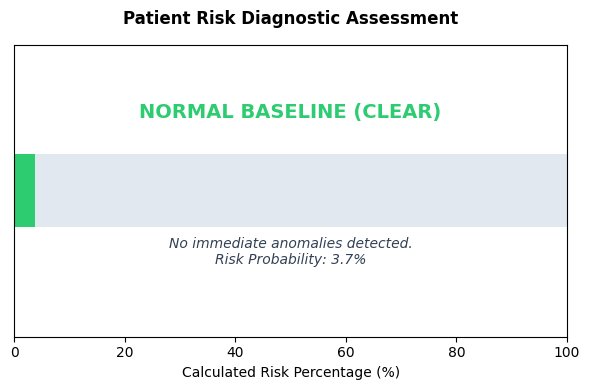

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# =====================================================================
# 1. COMPREHENSIVE DATASET (Simulated UCI Heart Disease Matrix)
# =====================================================================

clinical_records = [
    [63, 1, 3, 145, 233, 1, 0, 150, 0, 2.3, 0, 0, 1, 1],
    [37, 1, 2, 130, 250, 0, 1, 187, 0, 3.5, 0, 0, 2, 1],
    [41, 0, 1, 130, 204, 0, 0, 172, 0, 1.4, 2, 0, 2, 1],
    [56, 1, 1, 120, 236, 0, 1, 178, 0, 0.8, 2, 0, 2, 1],
    [57, 0, 0, 120, 354, 0, 1, 163, 1, 0.6, 2, 0, 2, 1],
    [57, 1, 0, 140, 192, 0, 1, 148, 0, 0.4, 1, 0, 1, 1],
    [56, 0, 1, 140, 294, 0, 0, 153, 0, 1.3, 1, 0, 2, 1],
    [44, 1, 1, 120, 263, 0, 1, 173, 0, 0.0, 2, 0, 3, 1],
    [52, 1, 2, 172, 199, 1, 1, 162, 0, 0.5, 2, 0, 3, 1],
    [57, 1, 2, 150, 168, 0, 1, 174, 0, 1.6, 2, 0, 2, 1],
    [54, 1, 0, 140, 239, 0, 1, 160, 0, 1.2, 2, 0, 2, 1],
    [48, 0, 2, 130, 275, 0, 1, 139, 0, 0.2, 2, 0, 2, 1],
    [49, 1, 1, 130, 266, 0, 1, 171, 0, 0.6, 2, 0, 2, 1],
    [64, 1, 3, 110, 211, 0, 0, 144, 1, 1.8, 1, 0, 2, 1],
    [58, 0, 3, 150, 283, 1, 0, 162, 0, 1.0, 2, 0, 2, 1],
    [50, 0, 2, 120, 219, 0, 1, 158, 0, 1.6, 1, 0, 2, 1],
    [58, 0, 2, 120, 340, 0, 1, 172, 0, 0.0, 2, 0, 2, 1],
    [66, 0, 3, 150, 226, 0, 1, 114, 0, 2.6, 0, 0, 2, 1],
    [43, 1, 0, 150, 247, 0, 1, 171, 0, 1.5, 2, 0, 2, 1],
    [69, 0, 3, 140, 239, 0, 1, 151, 0, 1.8, 2, 2, 2, 1],
    [59, 1, 0, 135, 234, 0, 1, 161, 0, 0.5, 1, 0, 3, 1],
    [44, 1, 0, 110, 197, 0, 0, 177, 0, 0.0, 2, 1, 2, 0],
    [60, 1, 0, 125, 258, 0, 0, 141, 1, 2.8, 1, 1, 3, 0],
    [56, 1, 0, 130, 283, 1, 0, 103, 1, 1.6, 0, 0, 3, 0],
    [44, 1, 0, 120, 169, 0, 1, 144, 1, 2.8, 0, 0, 1, 0],
    [58, 1, 0, 100, 234, 0, 1, 156, 0, 0.1, 2, 1, 3, 0],
    [50, 1, 0, 150, 243, 0, 0, 128, 0, 2.6, 1, 0, 3, 0],
    [54, 1, 0, 122, 286, 0, 0, 116, 1, 3.2, 1, 2, 2, 0],
    [57, 1, 0, 128, 303, 0, 0, 159, 0, 0.0, 2, 1, 2, 0],
    [71, 0, 0, 112, 149, 0, 1, 125, 0, 1.6, 1, 0, 2, 0],
    [59, 1, 0, 164, 176, 1, 0, 90, 0, 1.0, 1, 2, 1, 0],
    [57, 0, 0, 140, 241, 0, 1, 123, 1, 0.2, 1, 0, 3, 0],
    [47, 1, 2, 138, 257, 0, 0, 156, 0, 0.0, 2, 0, 2, 0],
    [35, 1, 0, 126, 282, 0, 0, 156, 1, 0.0, 2, 0, 3, 0],
    [58, 1, 0, 114, 318, 0, 2, 140, 0, 4.4, 0, 3, 1, 0],
    [57, 1, 0, 110, 201, 0, 1, 126, 1, 1.5, 1, 0, 1, 0],
    [58, 1, 0, 125, 300, 0, 0, 171, 0, 0.0, 2, 2, 3, 0],
    [43, 1, 0, 132, 247, 1, 0, 143, 1, 0.1, 1, 1, 3, 0],
    [62, 0, 0, 138, 294, 1, 1, 106, 0, 1.9, 1, 3, 2, 0],
    [51, 1, 0, 140, 299, 0, 1, 173, 1, 1.6, 2, 0, 3, 0]
]

feature_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.DataFrame(clinical_records, columns=feature_names)

# =====================================================================
# 2. DATA PREPROCESSING & DATA SPLIT
# =====================================================================
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=1, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training (Using Logistic Regression as our main evaluation engine)
logistic_engine = LogisticRegression(random_state=42)
logistic_engine.fit(X_train_scaled, y_train)

# =====================================================================
# 6. NEW PATIENT PREDICTION AND VISUALIZATION INTERFACE
# =====================================================================
def predict_and_visualize_patient(patient_features):
    """
    Takes raw patient clinical metrics, applies preprocessing,
    and shows a clean visual confirmation of risk status.
    """
    # 1. Format the data & scale it
    features_df = pd.DataFrame([patient_features], columns=X.columns)
    scaled_features = scaler.transform(features_df)

    # 2. Make prediction and compute risk probabilities
    prediction = logistic_engine.predict(scaled_features)[0]
    risk_probability = logistic_engine.predict_proba(scaled_features)[0][1] * 100

    # 3. Create simple Visual output
    plt.figure(figsize=(6, 4))

    # Colors depending on the severity outcome
    if prediction == 1:
        bg_color = '#e74c3c'      # Red
        status_text = "HEART DISEASE DETECTED"
        sub_text = f"The patient shows strong indicators of cardiovascular anomalies.\nRisk Probability: {risk_probability:.1f}%"
    else:
        bg_color = '#2ecc71'      # Green
        status_text = "NORMAL BASELINE (CLEAR)"
        sub_text = f"No immediate anomalies detected.\nRisk Probability: {risk_probability:.1f}%"

    # Plotting a clean, dashboard-like gauge banner
    plt.barh([0], [100], color='#e2e8f0', height=0.4) # Track background
    plt.barh([0], [risk_probability], color=bg_color, height=0.4) # Risk progress

    # Clean text-overlay positioning
    plt.text(50, 0.4, status_text, fontsize=14, weight='bold', color=bg_color, ha='center')
    plt.text(50, -0.4, sub_text, fontsize=10, color='#334155', ha='center', style='italic')

    plt.xlim(0, 100)
    plt.ylim(-0.8, 0.8)
    plt.title("Patient Risk Diagnostic Assessment", fontsize=12, pad=15, weight='bold')
    plt.xlabel("Calculated Risk Percentage (%)")
    plt.gca().get_yaxis().set_visible(False) # Turn off cluttering axis labels
    plt.tight_layout()
    plt.show()

# --- INPUT AREA ---
# Replace these values with any new client/patient matrix data to evaluate
# Template: [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal]
new_patient_data = [58, 1, 0, 114, 318, 0, 2, 140, 0, 4.4, 0, 3, 1]

# Execute interface
predict_and_visualize_patient(new_patient_data)